In [1]:
from tensorflow.keras.datasets import cifar10
from keras.layers import Input, Dense, Conv2D, BatchNormalization,Flatten, MaxPooling2D, Dropout
from keras import Sequential
from keras.callbacks import EarlyStopping
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import keras

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

2026-06-18 21:13:14.784661: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-18 21:13:14.837955: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-18 21:13:16.914095: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [4]:
y_train, y_test

(array([[6],
        [9],
        [9],
        ...,
        [9],
        [1],
        [1]], dtype=uint8),
 array([[3],
        [8],
        [8],
        ...,
        [5],
        [1],
        [7]], dtype=uint8))

In [5]:
# Remover uma dimensão redundante de y
y_train = y_train.squeeze()
y_test = y_test.squeeze()

y_train, y_test

(array([6, 9, 9, ..., 9, 1, 1], dtype=uint8),
 array([3, 8, 8, ..., 5, 1, 7], dtype=uint8))

In [6]:
class_names = ['airplane', 'automobile','bird','cat','deer','dog',
               'frog','horse','ship','truck']

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3), (50000,), (10000,))

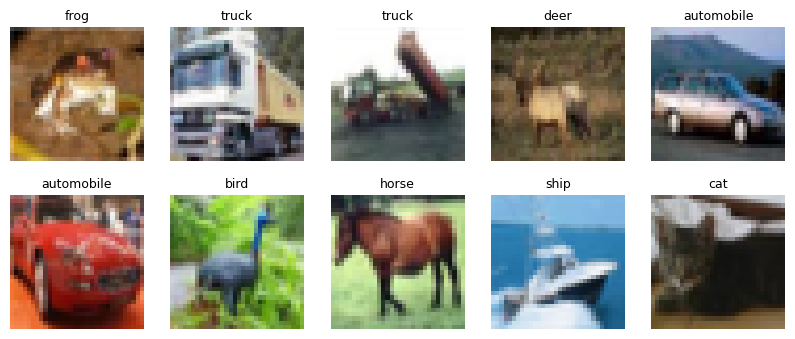

In [7]:
# Visualização
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]],fontsize=9)
    plt.axis("off")

plt.show()

In [8]:
# Pré processamento

X_train = (X_train.astype("float32")/255.0)
X_test = (X_test.astype("float32")/255.0)

In [9]:
X_train

array([[[[0.23137255, 0.24313726, 0.24705882],
         [0.16862746, 0.18039216, 0.1764706 ],
         [0.19607843, 0.1882353 , 0.16862746],
         ...,
         [0.61960787, 0.5176471 , 0.42352942],
         [0.59607846, 0.49019608, 0.4       ],
         [0.5803922 , 0.4862745 , 0.40392157]],

        [[0.0627451 , 0.07843138, 0.07843138],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509805, 0.21568628],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117648, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215687, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941177, 0.19607843],
         [0.47058824, 0.32941177, 0.19607843],
         [0.42745098, 0.28627452, 0.16470589]],

        ...,

        [[0.8156863 , 0.6666667 , 0.3764706 ],
         [0.7882353 , 0.6       , 0.13333334]

In [10]:
model = Sequential([
    Input(shape=(32,32,3)),
    Conv2D(32,3,activation='relu', padding="same"),
    MaxPooling2D(),
    Conv2D(64,3,activation='relu', padding="same"),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10,activation='softmax')
])

model.summary()


I0000 00:00:1781828002.258960  148428 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9702 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

er = EarlyStopping(
    min_delta=0.001,
    patience=5,
    restore_best_weights=True
)


In [12]:
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=128,
    callbacks=[er]
)

Epoch 1/100


2026-06-18 21:13:25.642809: I external/local_xla/xla/service/service.cc:163] XLA service 0x73653c005120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-18 21:13:25.642850: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-06-18 21:13:25.668329: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-18 21:13:25.939247: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92302


 28/352 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1596 - loss: 2.2544

I0000 00:00:1781828009.461493  148999 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


350/352 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3671 - loss: 1.7608

2026-06-18 21:13:32.923141: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_251', 28 bytes spill stores, 28 bytes spill loads

2026-06-18 21:13:33.002682: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_477', 100 bytes spill stores, 100 bytes spill loads



352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.3679 - loss: 1.7588 - val_accuracy: 0.5778 - val_loss: 1.2359
Epoch 2/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5820 - loss: 1.1933 - val_accuracy: 0.6212 - val_loss: 1.0945
Epoch 3/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6411 - loss: 1.0253 - val_accuracy: 0.6610 - val_loss: 0.9689
Epoch 4/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6748 - loss: 0.9321 - val_accuracy: 0.6736 - val_loss: 0.9369
Epoch 5/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7017 - loss: 0.8552 - val_accuracy: 0.6816 - val_loss: 0.9216
Epoch 6/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7260 - loss: 0.7936 - val_accuracy: 0.6962 - val_loss: 0.8835
Epoch 7/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7442 - loss: 0.7367 - val_accuracy: 0.6890 - val_loss: 0.8915
Epoch 8/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7637 - loss: 0.6872 - val_accuracy: 0.71

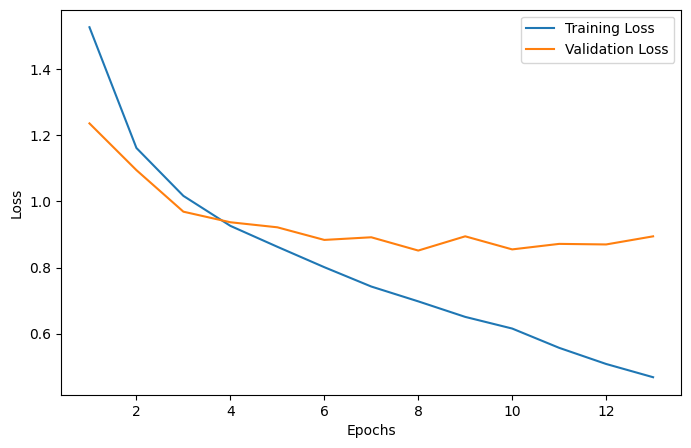

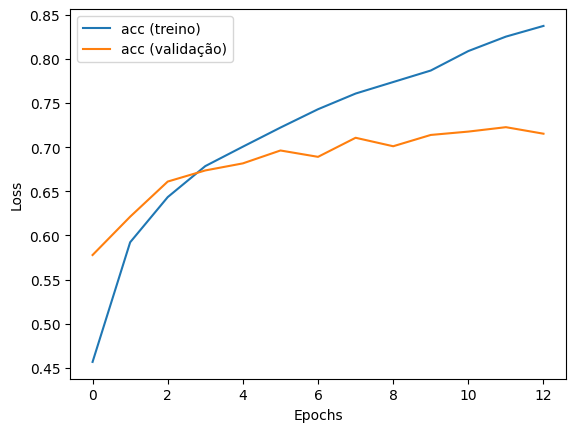

In [13]:
accuracy = history.history['accuracy']
loss = history.history['loss']
val_accuracy = history.history['val_accuracy']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(accuracy, label='acc (treino)')
plt.plot(val_accuracy, label='acc (validação)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [14]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"Teste - Loss:{test_loss:.4f} | accuracy: {test_acc:.4f}")

2026-06-18 21:14:07.789226: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_74', 20 bytes spill stores, 20 bytes spill loads



313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7053 - loss: 0.8595
Teste - Loss:0.8699 | accuracy: 0.7020


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


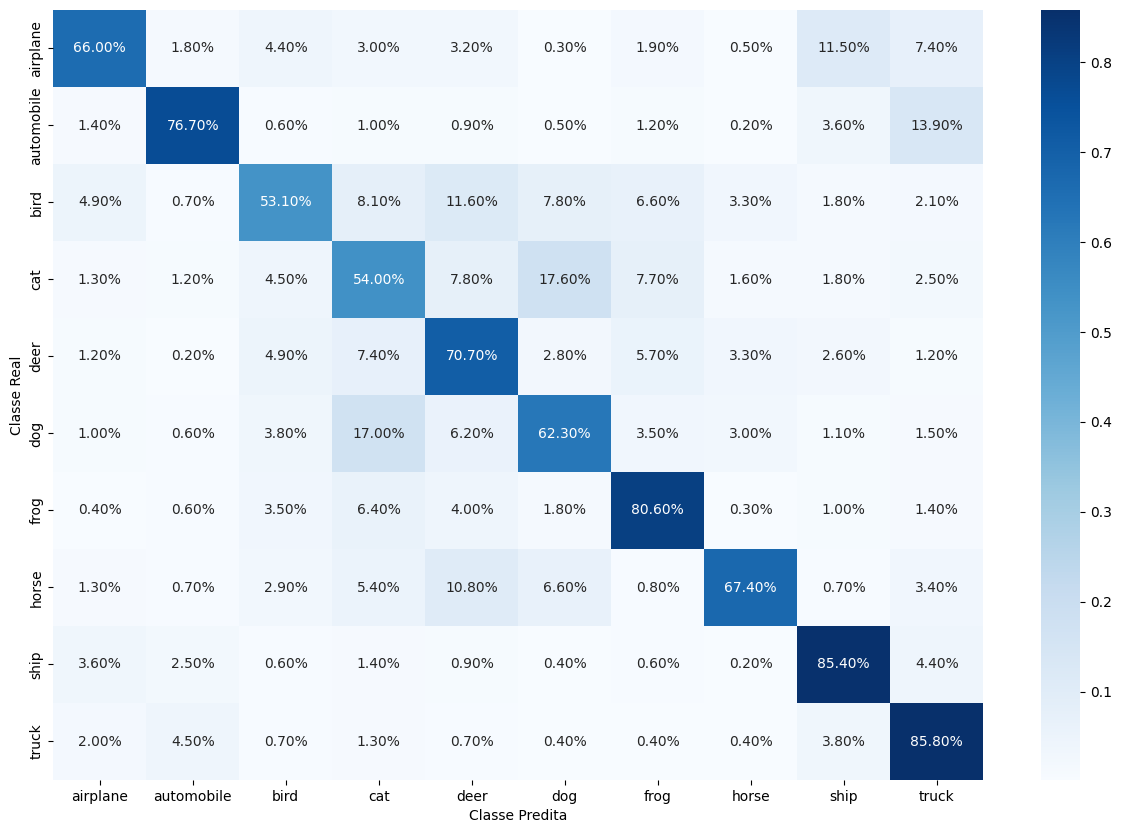

In [15]:
preds = np.argmax(model.predict(X_test), axis=1)


cm = confusion_matrix(y_test,preds, normalize='true')
plt.figure(figsize=(15,10))
sns.heatmap(
    cm,
    cmap="Blues",
    annot=True,
    fmt=".2%",
    xticklabels=class_names,
    yticklabels=class_names
)


plt.ylabel("Classe Real")
plt.xlabel("Classe Predita")

plt.show()

In [16]:
print(classification_report(y_test, preds, target_names=class_names))

              precision    recall  f1-score   support

    airplane       0.79      0.66      0.72      1000
  automobile       0.86      0.77      0.81      1000
        bird       0.67      0.53      0.59      1000
         cat       0.51      0.54      0.53      1000
        deer       0.61      0.71      0.65      1000
         dog       0.62      0.62      0.62      1000
        frog       0.74      0.81      0.77      1000
       horse       0.84      0.67      0.75      1000
        ship       0.75      0.85      0.80      1000
       truck       0.69      0.86      0.77      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.70     10000
weighted avg       0.71      0.70      0.70     10000



In [17]:
model.save("cnn_cifar10.keras")

In [18]:
# Inferência completa: Carregar o modelo e classificar uma imagem local
MODEL_PATH = "./cnn_cifar10.keras"
#IMG_PATH = "./data/Sample_1_CIFAR_10.jpg"
#IMG_PATH = "./data/Sample_2_CIFAR_10.jpg"
IMG_PATH = "./data/Sample_3_CIFAR_10.jpg"

In [19]:
# Carregar o modelo
model = tf.keras.models.load_model(MODEL_PATH)
img_original = image.load_img(IMG_PATH, target_size=(32,32))
img_arr = image.img_to_array(img_original)
img_arr = img_arr.astype("float32")/255.0

X = np.expand_dims(img_arr,axis=0)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 568ms/step
Imagem: ./data/Sample_3_CIFAR_10.jpg
Classe Prevista: dog (id=5)
Confiança: 0.9371


/tmp/ipykernel_148428/1249490839.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_id = int(np.argmax(probs, axis=1))


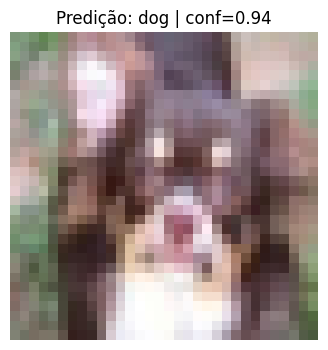

In [20]:
probs = model.predict(X)
pred_id = int(np.argmax(probs, axis=1))
pred_label = class_names[pred_id]
confidence = float(probs[0,pred_id])

print(f'Imagem: {IMG_PATH}')
print(f'Classe Prevista: {pred_label} (id={pred_id})')
print(f'Confiança: {confidence:.4f}')

plt.figure(figsize=(4,4))
plt.imshow(img_original)
plt.title(f'Predição: {pred_label} | conf={confidence:.2f}')
plt.axis("off")
plt.show()

In [4]:
import tensorflow as tf

MODEL_PATH = "./cnn_cifar10.keras"

model = tf.keras.models.load_model(MODEL_PATH)
model.export("/home/orlandojunior/estudos_ia/saved_model_cifar")  # export, não save!
print("Salvo!")

INFO:tensorflow:Assets written to: /home/orlandojunior/estudos_ia/saved_model_cifar/assets


INFO:tensorflow:Assets written to: /home/orlandojunior/estudos_ia/saved_model_cifar/assets


Saved artifact at '/home/orlandojunior/estudos_ia/saved_model_cifar'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  139823900441408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139823900439472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139823792692912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139823792712336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139823792331408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139823792330352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139823792387520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139823792386640: TensorSpec(shape=(), dtype=tf.resource, name=None)
Salvo!
